# Evaluation — Current Pipeline Comparison

All six variants scored on the hand-labelled benchmark (`thesis_benchmark_eval.csv`),
led by **toxic-class F1** because the set is heavily imbalanced toward normal content.
Includes the **LLM-Wiki** backend and the RAG-vs-Wiki comparison.

Re-run this after adding more labelled data — everything recomputes from the CSV.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

CSV = "../thesis_benchmark_eval.csv"
TOXIC = {"HATE", "OFFENSIVE"}

# (name, column) — the variants to compare, in order.
VARIANTS = [
    ("Tier-2 baseline",  "agent_final_decision"),
    ("+ memory",         "agent_final_decision_with_memory"),
    ("+ RAG",            "agent_final_decision_with_rag"),
    ("+ LLM-Wiki",       "agent_final_decision_with_wiki"),
    ("multi-agent",      "agent_final_decision_with_multi_agent"),
]

def effective_label(model_label, decision):
    d = str(decision).strip().lower()
    if d == "correct":        return str(model_label).upper()
    if d == "false positive": return "NORMAL"
    if d == "false negative": return "OFFENSIVE"
    return str(model_label).upper()

def metrics(pred, gt):
    pred, gt = pred.str.upper(), gt.str.upper()
    acc = (pred == gt).mean()
    pb, gb = pred.isin(TOXIC), gt.isin(TOXIC)
    bacc = (pb == gb).mean()
    tp = (pb & gb).sum(); fp = (pb & ~gb).sum(); fn = (~pb & gb).sum()
    rec  = tp/(tp+fn) if (tp+fn) else 0.0
    prec = tp/(tp+fp) if (tp+fp) else 0.0
    f1   = 2*prec*rec/(prec+rec) if (prec+rec) else 0.0
    return dict(n=len(pred), acc=acc, bacc=bacc, prec=prec, rec=rec, f1=f1)

df = pd.read_csv(CSV)
df["human_ground_truth"] = df["human_ground_truth"].fillna("").astype(str).str.strip().str.upper()
df["model_label"] = df["model_label"].astype(str).str.strip().str.upper()
df = df[df["human_ground_truth"].isin(["NORMAL", "OFFENSIVE", "HATE"])]
n_toxic = df["human_ground_truth"].isin(TOXIC).sum()
print(f"Labelled rows: {len(df)}  |  toxic: {n_toxic}  |  normal: {len(df)-n_toxic}")

Labelled rows: 1748  |  toxic: 80  |  normal: 1668


## 1. Comparison table

In [2]:
def variant_pred(sub, col):
    return sub.apply(lambda r: effective_label(r["model_label"], r[col]), axis=1)

rows = []
m = metrics(df["model_label"], df["human_ground_truth"])
rows.append(["Tier-1 DistilBERT", m["n"], m["acc"], m["bacc"], m["prec"], m["rec"], m["f1"]])
for name, col in VARIANTS:
    if col not in df.columns:
        continue
    sub = df[df[col].astype(str).str.strip().replace("nan", "").str.len() > 0]
    if sub.empty:
        continue
    m = metrics(variant_pred(sub, col), sub["human_ground_truth"])
    rows.append([name, m["n"], m["acc"], m["bacc"], m["prec"], m["rec"], m["f1"]])

table = pd.DataFrame(rows, columns=["Variant","n","3cls acc","bin acc","Tox P","Tox R","Tox F1"])
disp = table.copy()
disp["3cls acc"] = (disp["3cls acc"]*100).round(1).astype(str)+"%"
disp["bin acc"]  = (disp["bin acc"]*100).round(1).astype(str)+"%"
for c in ["Tox P","Tox R","Tox F1"]:
    disp[c] = disp[c].round(3)
disp

,Variant,n,3cls acc,bin acc,Tox P,Tox R,Tox F1
0,Tier-1 DistilBERT,1748,71.4%,72.0%,0.073,0.438,0.125
1,Tier-2 baseline,1748,90.2%,91.0%,0.272,0.575,0.369
2,+ memory,1748,89.9%,90.6%,0.250,0.525,0.339
3,+ RAG,1748,90.6%,91.4%,0.270,0.512,0.353
4,+ LLM-Wiki,1748,88.3%,89.1%,0.227,0.575,0.325
5,multi-agent,1748,92.6%,93.2%,0.333,0.475,0.392


## 2. Toxic-class F1 by variant

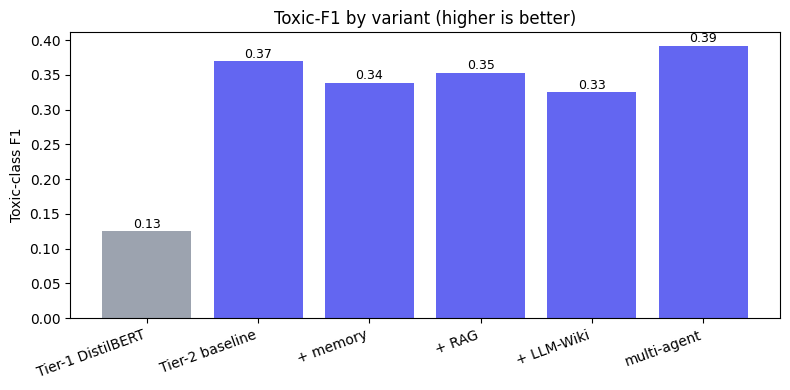

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#9ca3af"] + ["#6366f1"]*(len(table)-1)
ax.bar(table["Variant"], table["Tox F1"], color=colors)
ax.set_ylabel("Toxic-class F1"); ax.set_title("Toxic-F1 by variant (higher is better)")
for i, v in enumerate(table["Tox F1"]):
    ax.text(i, v+0.005, f"{v:.2f}", ha="center", fontsize=9)
plt.xticks(rotation=20, ha="right"); plt.tight_layout(); plt.show()

## 3. Precision / Recall / F1 on the toxic class

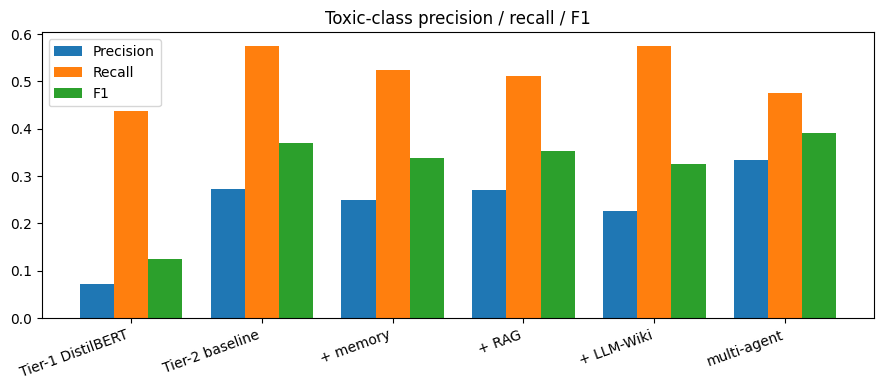

In [4]:
x = np.arange(len(table)); w = 0.26
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x-w, table["Tox P"], w, label="Precision")
ax.bar(x,   table["Tox R"], w, label="Recall")
ax.bar(x+w, table["Tox F1"], w, label="F1")
ax.set_xticks(x); ax.set_xticklabels(table["Variant"], rotation=20, ha="right")
ax.set_title("Toxic-class precision / recall / F1"); ax.legend()
plt.tight_layout(); plt.show()

## 4. Confusion matrices (toxic vs normal)

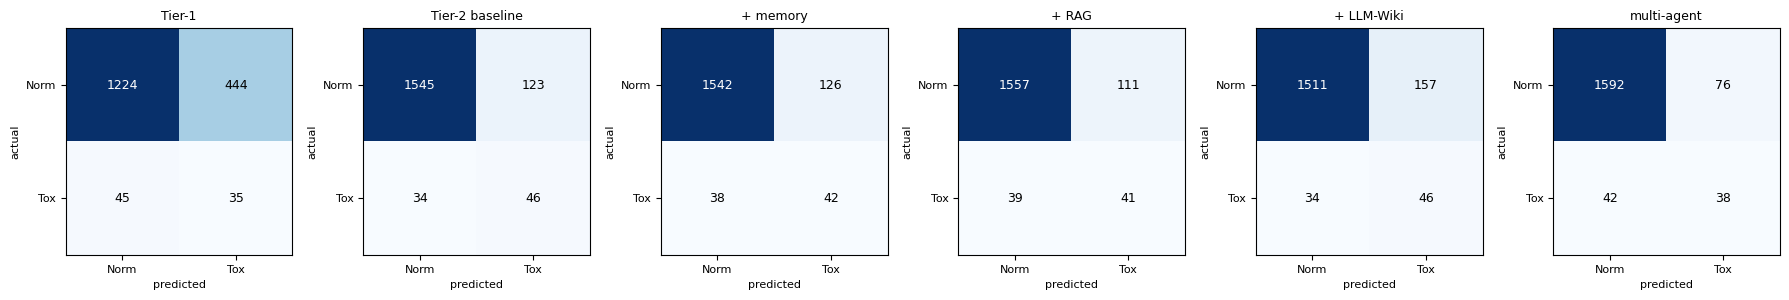

In [5]:
def binary_cm(pred, gt):
    pb, gb = pred.str.upper().isin(TOXIC), gt.str.upper().isin(TOXIC)
    return np.array([[((~pb)&(~gb)).sum(), (pb&(~gb)).sum()],
                     [((~pb)&gb).sum(),   (pb&gb).sum()]])

panels = [("Tier-1", "model_label", True)] + [(n, c, False) for n, c in VARIANTS if c in df.columns]
fig, axes = plt.subplots(1, len(panels), figsize=(3.0*len(panels), 3.0))
for ax, (name, col, is_t1) in zip(axes, panels):
    if is_t1:
        sub = df; pred = sub["model_label"]
    else:
        sub = df[df[col].astype(str).str.strip().replace("nan", "").str.len() > 0]
        pred = variant_pred(sub, col)
    cm = binary_cm(pred, sub["human_ground_truth"])
    ax.imshow(cm, cmap="Blues")
    ax.set_title(name, fontsize=9)
    ax.set_xticks([0,1]); ax.set_xticklabels(["Norm","Tox"], fontsize=8)
    ax.set_yticks([0,1]); ax.set_yticklabels(["Norm","Tox"], fontsize=8)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i,j], ha="center", va="center",
                    color="white" if cm[i,j] > cm.max()/2 else "black", fontsize=9)
    ax.set_xlabel("predicted", fontsize=8); ax.set_ylabel("actual", fontsize=8)
plt.tight_layout(); plt.show()

## 5. Statistical significance (McNemar vs baseline)

Only the *disagreements* count: how often the variant is right where the baseline is
wrong, versus the reverse. p < 0.05 means the difference is unlikely to be chance.

In [6]:
from scipy.stats import chi2

base_col = "agent_final_decision"
b0 = df[df[base_col].astype(str).str.strip().replace("nan", "").str.len() > 0].copy()
b0["base_correct"] = variant_pred(b0, base_col).str.upper().isin(TOXIC) == b0["human_ground_truth"].str.upper().isin(TOXIC)

print("McNemar vs baseline (toxic-vs-normal correctness):\n")
for name, col in VARIANTS[1:]:
    if col not in df.columns:
        continue
    sub = b0[b0[col].astype(str).str.strip().replace("nan", "").str.len() > 0].copy()
    sub["var_correct"] = variant_pred(sub, col).str.upper().isin(TOXIC) == sub["human_ground_truth"].str.upper().isin(TOXIC)
    b = ((sub["base_correct"]) & (~sub["var_correct"])).sum()   # baseline right, variant wrong
    c = ((~sub["base_correct"]) & (sub["var_correct"])).sum()   # variant right, baseline wrong
    if (b + c) == 0:
        print(f"  {name:<14s}: no disagreements"); continue
    stat = (abs(b - c) - 1)**2 / (b + c)
    p = 1 - chi2.cdf(stat, 1)
    print(f"  {name:<14s}: baseline-only-right={b:3d}  variant-only-right={c:3d}  "
          f"chi2={stat:5.2f}  p={p:.3f}  ({'significant' if p < 0.05 else 'not significant'})")

McNemar vs baseline (toxic-vs-normal correctness):

  + memory      : baseline-only-right= 63  variant-only-right= 56  chi2= 0.30  p=0.582  (not significant)
  + RAG         : baseline-only-right= 52  variant-only-right= 59  chi2= 0.32  p=0.569  (not significant)
  + LLM-Wiki    : baseline-only-right= 85  variant-only-right= 51  chi2= 8.01  p=0.005  (significant)
  multi-agent   : baseline-only-right= 40  variant-only-right= 79  chi2=12.13  p=0.000  (significant)


## Notes

- **Lead with Toxic-F1**, not accuracy: an "always normal" model scores very high
  accuracy here while catching nothing.
- With few toxic cases the McNemar test will often say *not significant* — that is the
  honest state, and the reason for growing the toxic set.
- Re-run top to bottom after each new batch of labels; the tables and charts update
  automatically.